In [1]:
# pip install pandas numpy matplotlib openpyxl

## DATASET OVERVIEW

In [2]:
from pathlib import Path
import pandas as pd
import gc
BASE_DIR = Path("..").resolve()          # app/
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = DATA_DIR / "outputs"


In [3]:

cols_needed = [
    "Anon Student Id",
    "Problem Name",
    "Step Name",
    "KC(Default)",
    "Correct First Attempt",
    "Incorrects",
    "Hints",
    "Corrects",
    "Step Start Time",
    "Step End Time",
]

cols_06 = cols_needed.copy()
cols_08 = [
    "Anon Student Id",
    "Problem Name",
    "Step Name",
    "KC(SubSkills)",
    "Correct First Attempt",
    "Incorrects",
    "Hints",
    "Corrects",
    "Step Start Time",
    "Step End Time",
]

dtype_06 = {
    "Anon Student Id": "category",
    "Problem Name": "category",
    "Step Name": "category",
    "KC(Default)": "category",
    "Correct First Attempt": "Int8",
    "Incorrects": "Int16",
    "Hints": "Int16",
    "Corrects": "Int16",
}

dtype_08 = {
    "Anon Student Id": "category",
    "Problem Name": "category",
    "Step Name": "category",
    "KC(SubSkills)": "category",
    "Correct First Attempt": "Int8",
    "Incorrects": "Int16",
    "Hints": "Int16",
    "Corrects": "Int16",
}

def load_06(path):
    return pd.read_csv(path, sep="\t", usecols=cols_06, dtype=dtype_06)

def load_08(path):
    df = pd.read_csv(path, sep="\t", usecols=cols_08, dtype=dtype_08)
    return df.rename(columns={
        "KC(SubSkills)": "KC(Default)",
    })

train_06 = load_06(RAW_DIR / "algebra_2006_2007_train.txt")
train_08 = load_08(RAW_DIR / "algebra_2008_2009_train.txt")

_df_train = pd.concat([train_06, train_08], ignore_index=True)

del train_06, train_08
gc.collect()

print("Train shape:", _df_train.shape)
print("Columns:", _df_train.columns.tolist())
print("Students:", _df_train["Anon Student Id"].nunique())
print("Problems:", _df_train["Problem Name"].nunique())
print("Steps:", _df_train["Step Name"].nunique())
print("KCs:", _df_train["KC(Default)"].nunique())
print(_df_train.head())


Train shape: (11188438, 10)
Columns: ['Anon Student Id', 'Problem Name', 'Step Name', 'Step Start Time', 'Step End Time', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects', 'KC(Default)']
Students: 4648
Problems: 270088
Steps: 1008868
KCs: 3288
  Anon Student Id Problem Name Step Name        Step Start Time  \
0           JG4Tz   LDEMO_WKST      R1C1  2006-10-26 09:51:58.0   
1           JG4Tz   LDEMO_WKST      R1C2  2006-10-26 09:53:30.0   
2           JG4Tz   LDEMO_WKST      R2C1  2006-10-26 09:53:41.0   
3           JG4Tz   LDEMO_WKST      R2C2  2006-10-26 09:53:46.0   
4           JG4Tz   LDEMO_WKST      R4C1  2006-10-26 09:53:50.0   

           Step End Time  Correct First Attempt  Incorrects  Hints  Corrects  \
0  2006-10-26 09:53:30.0                      0           2      0         1   
1  2006-10-26 09:53:41.0                      1           0      0         1   
2  2006-10-26 09:53:46.0                      1           0      0         1   
3  2006-10-26 09:53:50.

## Sample with each exercise once


## Helpers

In [4]:
import re
from collections import Counter
import re
import pandas as pd

def has_variable_inside_parentheses(step_name):
    if pd.isna(step_name):
        return False
    s = str(step_name).replace(" ", "")
    groups = re.findall(r'\(([^()]*)\)', s)
    return any(re.search(r'[a-zA-Z]', g) for g in groups)

def is_denominator_parentheses(step_name):
    if pd.isna(step_name):
        return False
    s = str(step_name).replace(" ", "")
    return bool(
        re.search(r'\([^=]+\)/', s) or
        re.search(r'/\([^=]+\)', s)
    )

def is_true_expand_eliminate_parentheses(step_name):
    if pd.isna(step_name):
        return False

    s = str(step_name).replace(" ", "")

    if "=" not in s:
        return False

    if "(" not in s or ")" not in s:
        return False

    # Excluir casos con denominadores
    if is_denominator_parentheses(s):
        return False

    # Exigir variable dentro del paréntesis
    if not has_variable_inside_parentheses(s):
        return False

    # Multiplicación/coeficiente aplicado al paréntesis
    patterns = [
        r'(\d+(\.\d+)?|[a-zA-Z])\([^=]+\)',   # 2(x+3), d(x+3), 0.5(x-1)
        r'\([^=]+\)(\d+(\.\d+)?|[a-zA-Z])',   # (x+3)2, (x+3)y
        r'-\([^=]+\)'                         # -(x+3)
    ]

    return any(re.search(p, s) for p in patterns)
# =========================================================
# STRICT HELPERS FOR COMBINE LIKE TERMS
# =========================================================
def get_equation_sides(step_name):
    if pd.isna(step_name):
        return None, None

    s = str(step_name).replace(" ", "")
    if "=" not in s:
        return None, None

    parts = s.split("=")
    if len(parts) != 2:
        return None, None

    return parts[0], parts[1]


def split_terms(expr):
    """
    Split an algebraic expression into signed terms.
    Example:
        '2x+3x-4' -> ['2x', '3x', '-4']
    """
    if expr is None:
        return []

    s = expr.replace(" ", "")
    s = s.replace("-", "+-")
    if s.startswith("+-"):
        s = s[1:]

    return [t for t in s.split("+") if t != ""]


def is_simple_variable_term(term):
    """
    Accept only simple variable terms such as:
        x, -x, 2x, -3x, 0.5x, 2*x
    Reject:
        x/3, x^2, sqrt(x), (x+1), xy
    """
    if term is None:
        return False

    t = term.replace(" ", "")

    # Reject clearly non-linear / complex forms
    banned = ["(", ")", "/", "^", "sqrt", "sin", "cos", "tan", "log", "ln"]
    if any(b in t.lower() for b in banned):
        return False

    patterns = [
        r"^-?[a-zA-Z]$",                         # x, -x
        r"^-?\d+(\.\d+)?[a-zA-Z]$",             # 2x, -3.5y
        r"^-?\d+(\.\d+)?\*[a-zA-Z]$",           # 2*x, -3.5*y
    ]

    return any(re.fullmatch(p, t) for p in patterns)


def get_term_variable(term):
    vars_found = re.findall(r"[a-zA-Z]", term)
    if len(vars_found) == 1:
        return vars_found[0]
    return None


def side_has_like_variable_terms(expr):
    """
    True if one side contains at least two simple terms with the same variable:
        2x+3x
        x+x
        -4y+7y
    """
    terms = split_terms(expr)

    var_terms = []
    for term in terms:
        if is_simple_variable_term(term):
            v = get_term_variable(term)
            if v is not None:
                var_terms.append(v)

    counts = Counter(var_terms)
    return any(count >= 2 for count in counts.values())


def has_only_one_distinct_variable(step_name):
    """
    Keep the KC narrow: only one variable symbol in the whole equation.
    """
    if pd.isna(step_name):
        return False

    s = str(step_name)
    vars_found = set(re.findall(r"[a-zA-Z]", s))
    return len(vars_found) == 1


def is_true_combine_like_terms(step_name):
    """
    Strict version of Combine Like Terms:
    - must be an equation
    - no parentheses / denominators / powers / functions
    - only one variable symbol overall
    - at least one side has repeated like variable terms
    """
    if pd.isna(step_name):
        return False

    s = str(step_name).replace(" ", "")

    if "=" not in s:
        return False

    banned_patterns = ["(", ")", "/", "^", "sqrt", "sin", "cos", "tan", "log", "ln"]
    if any(p in s.lower() for p in banned_patterns):
        return False

    if not has_only_one_distinct_variable(s):
        return False

    left, right = get_equation_sides(s)
    if left is None or right is None:
        return False

    return side_has_like_variable_terms(left) or side_has_like_variable_terms(right)

In [5]:
def map_kc(kc, step_name=None):
    if pd.isna(kc):
        return None

    kc_lower = str(kc).lower().strip()

    exclude_patterns = [
        "skillrule: variable in denominator;",
        "clt-r-den",
        "clt-r-num",
        "combine-like-terms-r-sp",
    ]
    if any(p in kc_lower for p in exclude_patterns):
        return "Other"

    # 1. Expand / Eliminate Parentheses
    if (
        "skillrule: eliminate parens;" in kc_lower
        or "skillrule: calculate eliminate parens;" in kc_lower
        or "skillrule: do eliminate parens - whole;" in kc_lower
        or "skillrule: extract to consolidate vars;" in kc_lower
        or "skillrule: select eliminate parens" in kc_lower
    ):
        if is_true_expand_eliminate_parentheses(step_name):
            return "Expand / Eliminate Parentheses"
        return "Other"

    # 2. Combine Like Terms (STRICT: only variable consolidation)
    if (
        "skillrule: do combine terms - whole;" in kc_lower
        or "skillrule: consolidate vars, no coeff;" in kc_lower
        or "skillrule: consolidate vars with coeff;" in kc_lower
        or "skillrule: consolidate vars, any;" in kc_lower
    ):
        if is_true_combine_like_terms(step_name):
            return "Combine Like Terms"
        return "Other"

    # Optional CLT fallback, but only if the step really looks like CLT
    if (
        "clt" in kc_lower
        and "parens" not in kc_lower
        and "consolidate vars" not in kc_lower
        and "r-den" not in kc_lower
        and "r-num" not in kc_lower
    ):
        if is_true_combine_like_terms(step_name):
            return "Combine Like Terms"
        return "Other"

    # Explicitly exclude constant-only CLT / generic arithmetic
    if (
        "skillrule: combine like terms, no var;" in kc_lower
        or "skillrule: add/subtract" in kc_lower
        or "skillrule: add/substract" in kc_lower
    ):
        return "Other"

    # 3. Move Constants Across the Equation
    if (
        "skillrule: remove constant;" in kc_lower
        or "skillrule: ax+b=c, negative;" in kc_lower
        or "skillrule: isolate positive;" in kc_lower
        or "skillrule: isolate negative;" in kc_lower
    ):
        return "Move Constants Across the Equation"

    # 4. Remove Coefficient
    if (
        "skillrule: remove coefficient;" in kc_lower
        or "skillrule: remove positive coefficient;" in kc_lower
        or "skillrule: remove negative coefficient;" in kc_lower
        or "skillrule: multiply/divide;" in kc_lower
        or "[solveroperation multiply]" in kc_lower
        or "[solveroperation divide]" in kc_lower
        or "solveroperation mt" in kc_lower
        or "solveroperation rf" in kc_lower
        or "rf right" in kc_lower
        or "rf left" in kc_lower
    ):
        return "Remove Coefficient"

    # 5. Normalize Negative Variable / Sign
    if (
        "skillrule: make variable positive;" in kc_lower
        or "skillrule: calculate negative coefficient;" in kc_lower
    ):
        return "Normalize Negative Variable / Sign"

    return "Other"
def convert_time_columns(df):
    time_cols = [
        "Step Start Time",
        "Step End Time"
    ]
    for col in time_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def convert_numeric_columns(df):
    numeric_cols = [
        "Correct First Attempt",
        "Incorrects",
        "Hints",
        "Corrects",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def is_linear_equation_step(step_name):
    """
    Keep only rows that look like simple first-degree linear equation steps.
    """
    if pd.isna(step_name):
        return False

    step = str(step_name).lower().strip()

    if "=" not in step:
        return False

    # Off-domain / non-linear / obviously irrelevant patterns
    banned_patterns = [
        "sqrt", "^", "hypotenuse", "slope", "geometry",
        "probability", "median", "mean", "mode", "ratio",
        "scientific notation", "axis", "plot", "graph",
        "quadrat", "exponent", "compare", "action",
        "unspecified", "unknown", "any form", "entering a",
        "sin", "cos", "tan", "log", "ln", "abs"
    ]

    if any(p in step for p in banned_patterns):
        return False

    return True

def preprocess_kc(
    df,
    remove_other=False,
    drop_original_kc_cols=False,
    filter_irrelevant=False
):
    df = df.dropna(subset=[
        "Anon Student Id",
        "KC(Default)",
        "Correct First Attempt",
        "Step Start Time"
    ]).copy()

    df = df[df["Step Name"].apply(is_linear_equation_step)].copy()


    # Optional domain filtering
    if filter_irrelevant:
        irrelevant_patterns = [
            "action", "compare", "axis", "-row",
            "unspecified", "unknown", "any form", "entering a",
            "plot", "graph", "probability", "median", "mean",
            "mode", "rate", "ratio", "scientific notation", "slope",
            "square root", "hypotenuse", "geometry", "quadrat", "exponent"
        ]

        mask = ~df["KC(Default)"].astype(str).str.lower().apply(
            lambda x: any(pattern in x for pattern in irrelevant_patterns)
        )
        df = df[mask]

    # Split multi-KC rows
    df["KC"] = df["KC(Default)"].astype(str).str.split("~~")

    # One row per KC
    df = df.explode("KC")
    input_rows = df.shape[0]

    # Clean KC values
    df["KC"] = df["KC"].astype(str).str.strip()
    df = df[df["KC"] != ""]
    df = df[df["KC"].str.lower() != "nan"]


    # Map to reduced KC taxonomy
    df["skill_name"] = df.apply(
        lambda row: map_kc(row["KC"], row["Step Name"]),
        axis=1
    )
    if remove_other:
        df = df[df["skill_name"] != "Other"]

    if drop_original_kc_cols:
        cols_to_drop = [col for col in ["KC(Default)", "KC"] if col in df.columns]
        df = df.drop(columns=cols_to_drop)

    df = df.reset_index(drop=True)
    output_rows = df.shape[0]

    print(f"Dataset input rows: {input_rows}")
    print(f"Dataset output rows: {output_rows}\n")

    return df


## KC election

Some steps have multiple KCs associated with them; when this occurs, they are separated by ~~. In this section, we create one row per KC and then classify them to obtain a reduced and interpretable set of KCs related to first-degree linear equations:
1. Expand / Eliminate Parentheses: removing or expanding parentheses through the distributive property or equivalent transformations.
2. Move Constants Across the Equation: using inverse addition or subtraction to transfer constant terms from one side of the equation to the other.
3. Combine Like Terms: simplifying expressions by combining terms of the same type on the same side of the equation.
4. Remove Coefficient: eliminating the coefficient of the variable, typically through multiplication or division, in order to isolate it.
5. Normalize Negative Variable / Sign: handling negative signs so that the variable is rewritten with a positive coefficient.

In [6]:
# df = _df_train[cols_needed].copy()

# df = preprocess_kc(df, remove_other=True, filter_irrelevant=True)

# # 4. BUILD MAIN KC -> PROBLEM -> STEP TABLE
# kc_problem_step = (
#     df.groupby(["KC", "skill_name", "Problem Name", "Step Name"])
#       .agg(
#           appearances=("KC", "size"),
#           students=("Anon Student Id", "nunique"),
#           avg_correct=("Correct First Attempt", "mean")
#       )
#       .reset_index()
#       .sort_values(["skill_name", "appearances"], ascending=[True, False])
# )

# # 5. UNIQUE KCs WITH COUNTS
# kc_summary = (
#     df.groupby("KC")
#       .agg(
#           total_appearances=("KC", "size"),
#           n_problems=("Problem Name", "nunique"),
#           n_steps=("Step Name", "nunique"),
#           n_students=("Anon Student Id", "nunique"),
#           avg_correct=("Correct First Attempt", "mean")
#       )
#       .reset_index()
#       .sort_values("total_appearances", ascending=False)
# )

# # 6. EXPORT FOR MANUAL REVIEW
# kc_problem_step.to_csv(RAW_DIR / "kc_problem_step_mapping.csv", index=False)
# kc_summary.to_csv(RAW_DIR / "kc_summary.csv", index=False)


## Dataset Processing

Final dataset with only relevant KC columns

In [7]:
df_train = convert_time_columns(_df_train)
del _df_train
gc.collect()
# df_test = convert_time_columns(df_test)

df_train = convert_numeric_columns(df_train)
# df_test = convert_numeric_columns(df_test)

df_train = preprocess_kc(df_train,remove_other=True,drop_original_kc_cols=True,filter_irrelevant=True)
# df_test = preprocess_kc(df_test,remove_other=True,drop_original_kc_cols=True,filter_irrelevant=True)

# Sort in true chronological order per student
df_train = df_train.sort_values(
    by=["Anon Student Id", "Step Start Time", "Problem Name", "Step Name"]
).reset_index(drop=True)

# df_test = df_test.sort_values(
#     by=["Anon Student Id", "Step Start Time", "Problem Name", "Step Name"]
# ).reset_index(drop=True)

# REMOVE DUPLICATES
# Include Step Start Time to preserve separate interactions
subset_cols = [
    "Anon Student Id",
    "Problem Name",
    "Step Name",
    "skill_name",
    "Step Start Time"
]

duplicates_train = df_train.duplicated(subset=subset_cols)
# duplicates_test = df_test.duplicated(subset=subset_cols)

n_duplicates_train = duplicates_train.sum()
# n_duplicates_test = duplicates_test.sum()

percentage_train = (n_duplicates_train / len(df_train)) * 100 if len(df_train) > 0 else 0
# percentage_test = (n_duplicates_test / len(df_test)) * 100 if len(df_test) > 0 else 0

print(f"Train duplicated interactions: {n_duplicates_train}")
print(f"Train duplicate percentage: {percentage_train:.2f}%")

# print(f"Test duplicated interactions: {n_duplicates_test}")
# print(f"Test duplicate percentage: {percentage_test:.2f}%")

df_train = df_train.drop_duplicates(subset=subset_cols).reset_index(drop=True)
# df_test = df_test.drop_duplicates(subset=subset_cols).reset_index(drop=True)

print("Remaining train duplicates:", df_train.duplicated(subset=subset_cols).sum())
# print("Remaining test duplicates:", df_test.duplicated(subset=subset_cols).sum())

# =========================================================
# FINAL DATASET INFO
# =========================================================
print("\nFINAL TRAIN DATASET")
print("Shape:", df_train.shape)
print("Columns:", df_train.columns.to_list())
print("Number of students:", df_train["Anon Student Id"].nunique())
print("Number of problems:", df_train["Problem Name"].nunique())
print("Number of steps:", df_train["Step Name"].nunique())
print("Number of reduced KCs:", df_train["skill_name"].nunique())

print("\nReduced KC counts:")
print(df_train["skill_name"].value_counts())


Dataset input rows: 2245300
Dataset output rows: 1090016

Train duplicated interactions: 363209
Train duplicate percentage: 33.32%
Remaining train duplicates: 0

FINAL TRAIN DATASET
Shape: (726807, 10)
Columns: ['Anon Student Id', 'Problem Name', 'Step Name', 'Step Start Time', 'Step End Time', 'Correct First Attempt', 'Incorrects', 'Hints', 'Corrects', 'skill_name']
Number of students: 3099
Number of problems: 149255
Number of steps: 333506
Number of reduced KCs: 5

Reduced KC counts:
skill_name
Remove Coefficient                    352053
Move Constants Across the Equation    273497
Expand / Eliminate Parentheses         51614
Combine Like Terms                     32968
Normalize Negative Variable / Sign     16675
Name: count, dtype: int64


## Final cleaned files

In [8]:
train_file = PROCESSED_DIR / "df_train_kc_cleaned_2006-2009_3.csv"
# test_file = PROCESSED_DIR / "df_test_kc_cleaned.csv"

df_train.to_csv(train_file, index=False)
# df_test.to_csv(test_file, index=False)

print(f"Saved: {train_file}")

Saved: /mnt/c/Users/Melany Nuria/Desktop/TFG/adaptive_bayesian_its/backend_fastAPI/app/data/processed/df_train_kc_cleaned_2006-2009_3.csv


           skill_name Anon Student Id  n_interactions
0  Combine Like Terms         0I891Gg               2
1  Combine Like Terms        171051xl               4
2  Combine Like Terms        1710gLX8              14
3  Combine Like Terms        17116XP9              13
4  Combine Like Terms        1712aRVk               1


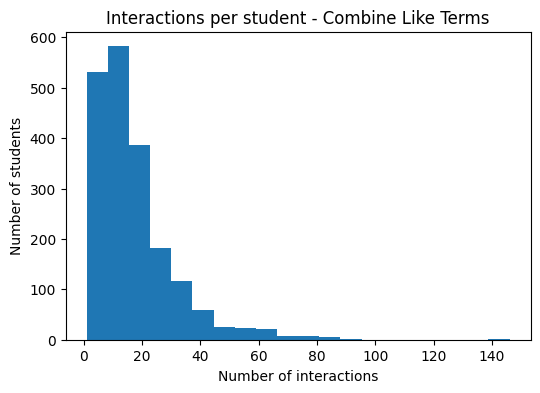

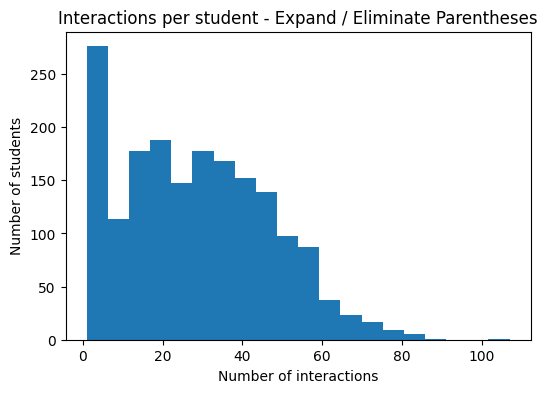

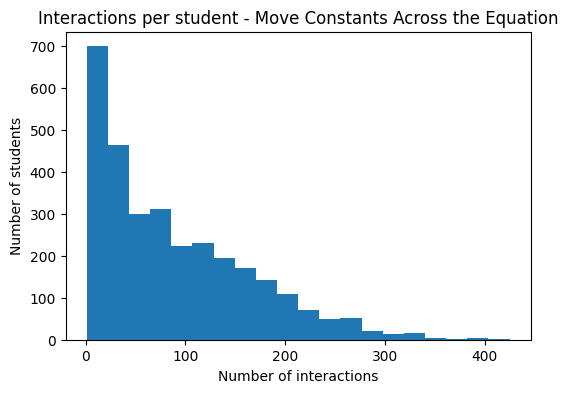

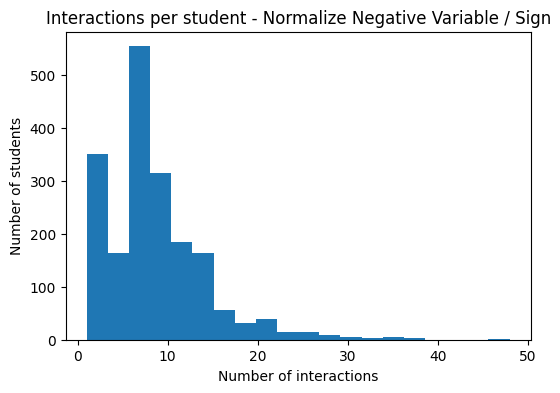

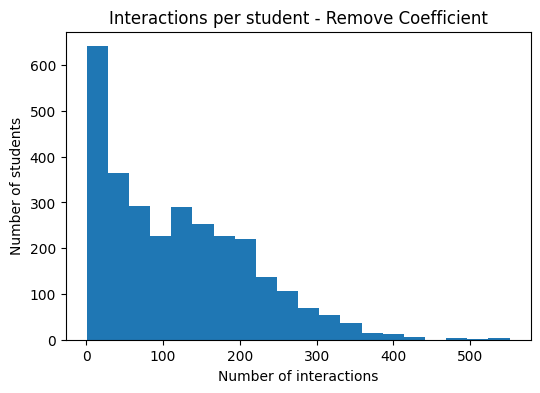

In [9]:
import matplotlib.pyplot as plt
interactions_per_student_skill = (
    df_train.groupby(["skill_name", "Anon Student Id"])
    .size()
    .reset_index(name="n_interactions")
)

print(interactions_per_student_skill.head())
for skill in interactions_per_student_skill["skill_name"].unique():
    sub = interactions_per_student_skill[
        interactions_per_student_skill["skill_name"] == skill
    ]

    plt.figure(figsize=(6,4))
    plt.hist(sub["n_interactions"], bins=20)
    plt.title(f"Interactions per student - {skill}")
    plt.xlabel("Number of interactions")
    plt.ylabel("Number of students")
    plt.show()

Notas: 
- cata studiante tiene su P(L) prob. of learning 
- este dataset nos ayuda a obtener las probabilidades Pl0, pt, pg, ps para cada KC 
- despues de cada ejercicio realizadp la P(L) del estudiante se actualiza